In [1]:

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV
from pygam import LinearGAM
import matplotlib.cm as cm
from scipy.stats import linregress, pearsonr


%load_ext autoreload
%autoreload 2

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
from GLM_regression_plotting import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

from utils import get_synthetic_data as utils_get_synthetic_data


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")

activity_dict_SST, factors_dict_SST = preprocess_data(filepath_SST, normalize=True)
activity_dict_NDNF, factors_dict_NDNF = preprocess_data(filepath_NDNF, normalize=True)
activity_dict_EC, factors_dict_EC = preprocess_data(filepath_EC, normalize=True)

filtered_factors_dict_SST = subset_variables_from_data(factors_dict_SST, variables_to_keep=["Velocity"])
filtered_factors_dict_NDNF = subset_variables_from_data(factors_dict_NDNF, variables_to_keep=["Velocity"])
filtered_factors_dict_EC = subset_variables_from_data(factors_dict_EC, variables_to_keep=["Velocity"])


GLM_params_SST, predicted_activity_dict_SST = fit_GLM_population(filtered_factors_dict_SST, activity_dict_SST, quintile=None, regression='ridge', renormalize=True, alphas=None)

GLM_params_NDNF, predicted_activity_dict_NDNF = fit_GLM_population(filtered_factors_dict_NDNF, activity_dict_NDNF, quintile=None, regression='ridge', renormalize=True, alphas=None)
    
GLM_params_EC, predicted_activity_dict_EC = fit_GLM_population(filtered_factors_dict_EC, activity_dict_EC, quintile=None, regression='ridge', renormalize=True, alphas=None)



C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


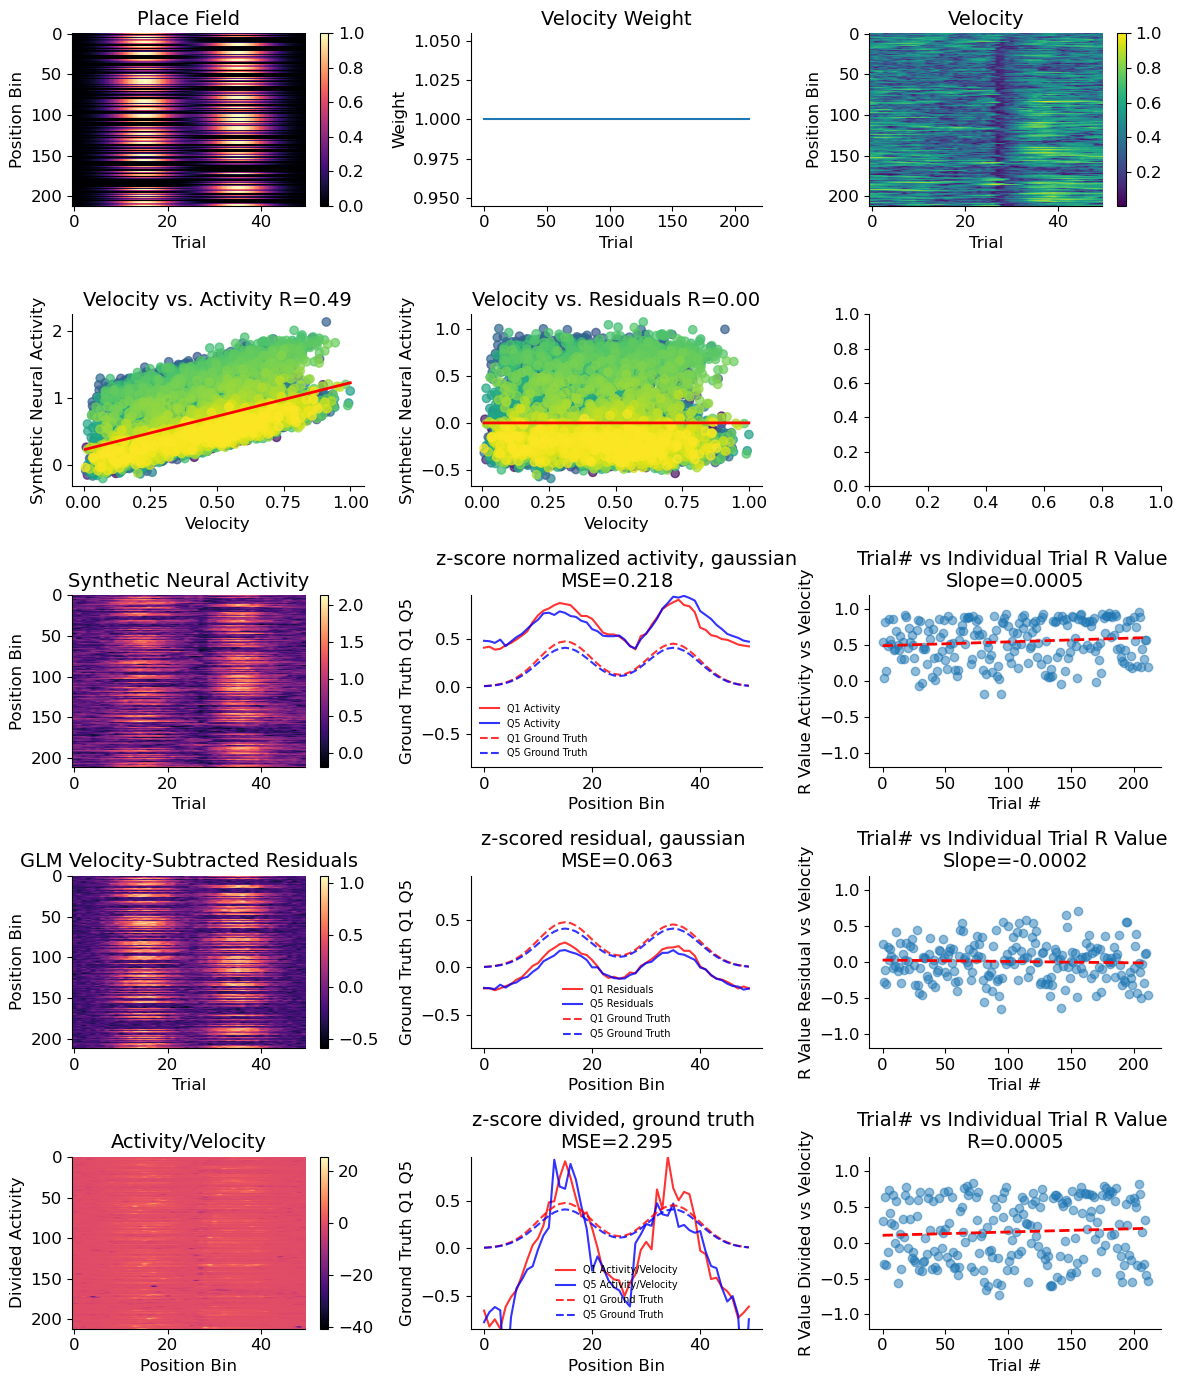

In [8]:


MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, residual, combined_activity, divided_array, predicted_array, place_field_type, z_score = get_synthetic_data(activity_dict_SST, factors_dict_SST, velocity_weight_type="flat", noise_scale=0.1, place_field_type="EC", use_GAM=False, velocity_power=1, velocity_weight=1, place_field_shift=0, place_field_scale=1, z_score=False)

plot_synthetic_data(MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, combined_activity, predicted_array, residual, divided_array, place_field_type, z_score=False)
 
    

#place field options : "flat", "positive_ramp", "negative_ramp", "step"
   
    

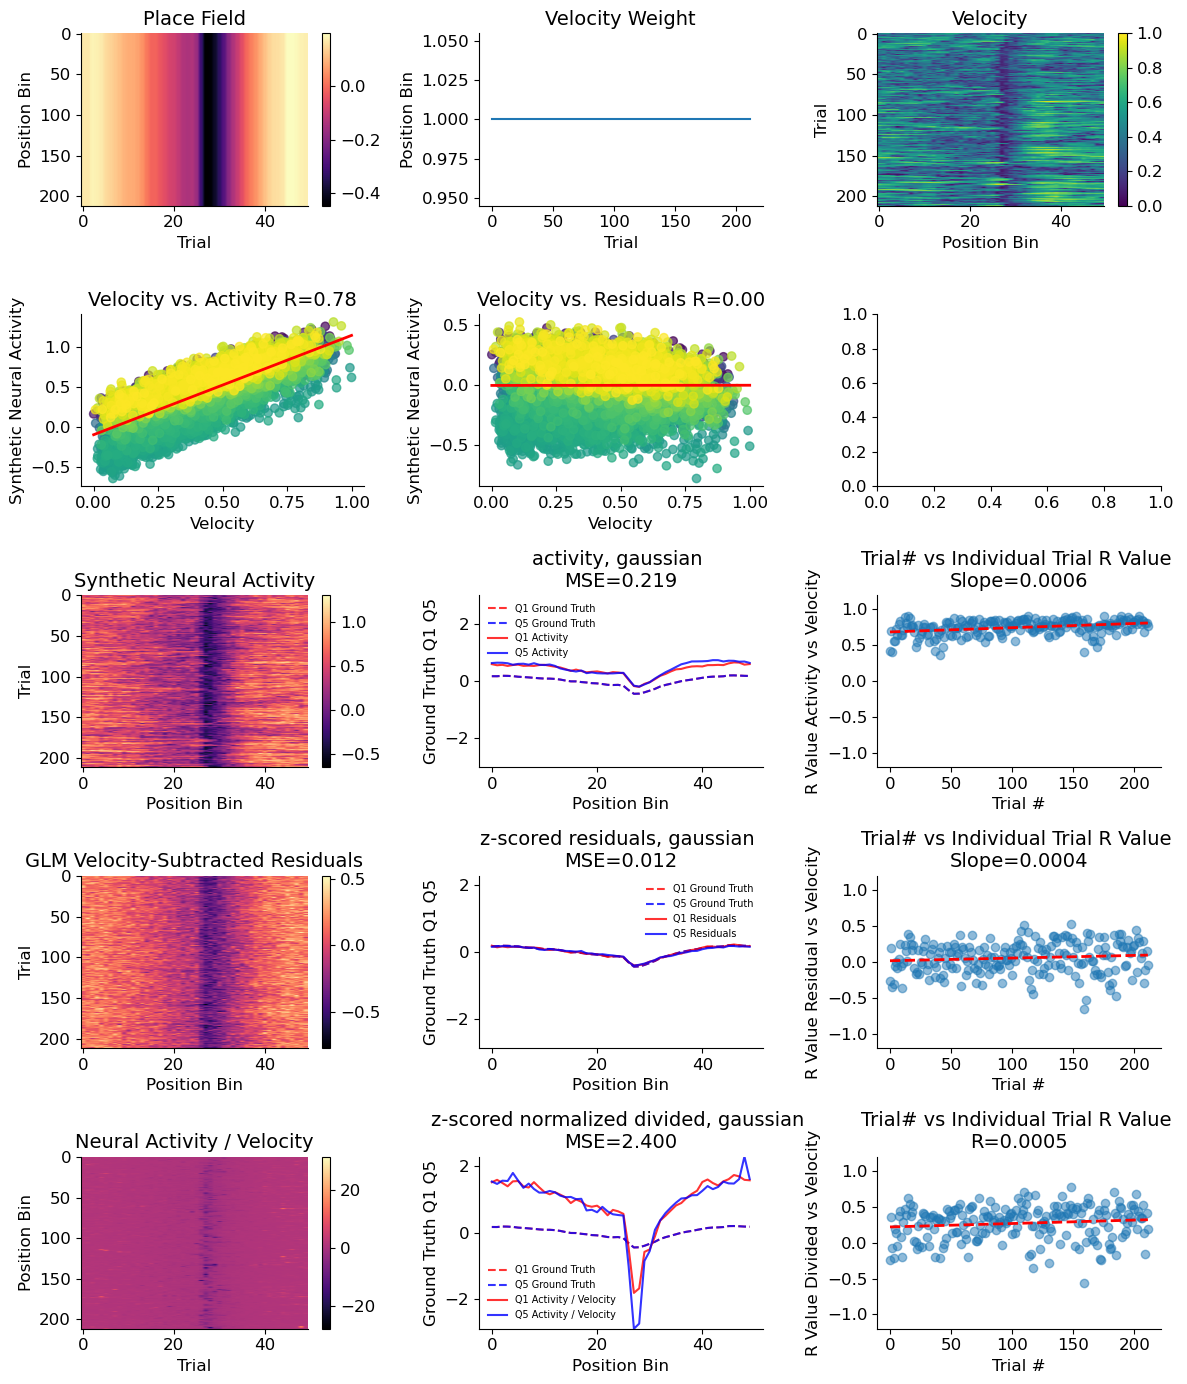

In [10]:

MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, residual_array, combined_activity, divided_array, predicted_array, place_field_type, z_score = get_synthetic_data_seperate_quintiles(activity_dict_SST, factors_dict_SST, velocity_weight_type="ramping_weight", noise_scale=0.1, place_field_type="flat", use_GAM=False, velocity_power=1, velocity_weight=1, place_field_shift=0, place_field_scale=0, z_score=False)

    
plot_synthetic_data_seperate_quintiles(MSE_activity, MSE_residual, MSE_divided, place_field, velocity, residual_array, combined_activity, divided_array, predicted_array, velocity_weight, place_field_type=place_field_type, z_score=z_score)
       

which_MSE=residual


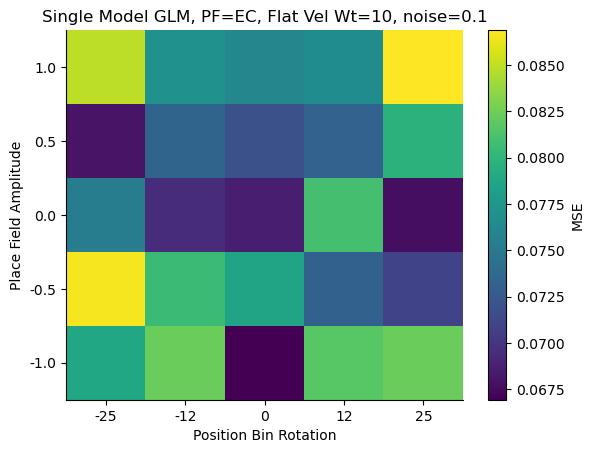

In [71]:
get_MSE_array_and_plot(activity_dict_SST, factors_dict_SST, velocity_weight_type="flat", noise_scale=0.1, place_field_type="EC", use_GAM=False, velocity_power=1, velocity_weight=10, multimodel=False, z_score=False, which_MSE="residual")
  
    
#Place Field Options flat, positive_ramp, negative_ramp, step, BTSP, EC